# Baseline Emotion Classification Model

## Purpose

This notebook develops and evaluates the baseline machine-learning model for the Emotional Wellbeing Analysis System.

The baseline approach uses:

- TF-IDF for text feature extraction
- Logistic Regression for emotion classification

The model is trained using the cleaned training dataset and evaluated using the cleaned validation dataset.

The test dataset will be kept separate and will not be used during baseline model development or tuning. It will be reserved for final evaluation after the preferred model has been selected.

The emotion classes are:

1. Sadness
2. Joy
3. Love
4. Anger
5. Fear
6. Surprise

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

## 1. Load the Cleaned Dataset

The cleaned training, validation, and test datasets produced during the dataset preprocessing stage are loaded below.

The training dataset will be used to fit the baseline model.

The validation dataset will be used to evaluate and compare model-development decisions.

The test dataset is loaded only to verify its availability and structure. It will remain unused during baseline development and will be reserved for final model evaluation.

In [2]:
CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parents[1]
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

PROCESSED_DATA_DIR = PROJECT_ROOT / "ml" / "data" / "processed"

print("Current directory:", CURRENT_DIRECTORY)
print("Project root:", PROJECT_ROOT)
print("Processed data directory:", PROCESSED_DATA_DIR)

Current directory: /mnt/c/Final Year Project/emotional-wellbeing-system/ml/notebooks
Project root: /mnt/c/Final Year Project/emotional-wellbeing-system
Processed data directory: /mnt/c/Final Year Project/emotional-wellbeing-system/ml/data/processed


In [3]:
train_path = PROCESSED_DATA_DIR / "emotion_train_clean.csv"
validation_path = PROCESSED_DATA_DIR / "emotion_validation_clean.csv"
test_path = PROCESSED_DATA_DIR / "emotion_test_clean.csv"

train_df = pd.read_csv(train_path)
validation_df = pd.read_csv(validation_path)
test_df = pd.read_csv(test_path)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Training shape: (15923, 2)
Validation shape: (1988, 2)
Test shape: (1986, 2)


In [4]:
display(train_df.head())
display(validation_df.head())
display(test_df.head())

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


,text,label
0,im feeling quite sad and sorry for myself but ...,0
1,i feel like i am still looking at a blank canv...,0
2,i feel like a faithful servant,2
3,i am just feeling cranky and blue,3
4,i can have for a treat or if i am feeling festive,1


,text,label
0,im feeling rather rotten so im not very ambiti...,0
1,im updating my blog because i feel shitty,0
2,i never make her separate from me because i do...,0
3,i left with my bouquet of red and yellow tulip...,1
4,i was feeling a little vain when i did this one,0


In [5]:
print("Training columns:", train_df.columns.tolist())
print("Validation columns:", validation_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

print("\nTraining label counts:")
print(train_df["label"].value_counts().sort_index())

Training columns: ['text', 'label']
Validation columns: ['text', 'label']
Test columns: ['text', 'label']

Training label counts:
label
0    4661
1    5340
2    1283
3    2152
4    1923
5     564
Name: count, dtype: int64


## 2. Prepare Features and Labels

The input text and emotion labels are separated into feature and target variables.

The training split is used to fit the TF-IDF vectorizer and the Logistic Regression classifier.

The validation split is transformed using the already-fitted TF-IDF vectorizer and is used to evaluate the baseline model.

The test split remains reserved for later final evaluation.

In [6]:
X_train_text = train_df["text"]
y_train = train_df["label"]

X_validation_text = validation_df["text"]
y_validation = validation_df["label"]

X_test_text = test_df["text"]
y_test = test_df["label"]

print("Training texts:", X_train_text.shape)
print("Training labels:", y_train.shape)

print("Validation texts:", X_validation_text.shape)
print("Validation labels:", y_validation.shape)

print("Test texts:", X_test_text.shape)
print("Test labels:", y_test.shape)

Training texts: (15923,)
Training labels: (15923,)
Validation texts: (1988,)
Validation labels: (1988,)
Test texts: (1986,)
Test labels: (1986,)


## 3. TF-IDF Feature Extraction

TF-IDF converts the text into numerical features that can be used by the Logistic Regression classifier.

The vectorizer is fitted only on the training text to avoid information leakage from the validation or test datasets.

The validation and test text are transformed using the vocabulary and IDF values learned from the training data.

In [7]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=20000,
    ngram_range=(1, 2),
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)

X_validation_tfidf = tfidf_vectorizer.transform(X_validation_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_validation_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

print("Vocabulary size:", len(tfidf_vectorizer.vocabulary_))

Training TF-IDF shape: (15923, 20000)
Validation TF-IDF shape: (1988, 20000)
Test TF-IDF shape: (1986, 20000)
Vocabulary size: 20000


## 4. Train the Baseline Logistic Regression Model

A Logistic Regression classifier is trained using the TF-IDF features from the cleaned training dataset.

This model acts as the baseline machine-learning approach for the project and will later be compared with alternative configurations and the advanced transformer-based model.

The model is evaluated on the validation dataset so that the final test dataset remains untouched during model development.

In [8]:
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

baseline_model.fit(X_train_tfidf, y_train)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


## 5. Validation Predictions

The trained baseline model is used to predict emotion labels for the validation dataset.

These predictions are used to evaluate how well the baseline model generalises to unseen data that was not used during training.

In [9]:
y_validation_pred = baseline_model.predict(X_validation_tfidf)

print("Number of validation predictions:", len(y_validation_pred))
print("First 10 predicted labels:", y_validation_pred[:10])
print("First 10 actual labels:", y_validation.iloc[:10].to_list())

Number of validation predictions: 1988
First 10 predicted labels: [0 0 2 3 1 1 1 1 1 0]
First 10 actual labels: [0, 0, 2, 3, 1, 1, 1, 1, 1, 0]


## 6. Baseline Validation Evaluation

The baseline Logistic Regression model is evaluated on the validation dataset using multiple performance metrics.

Because the class distribution is imbalanced, accuracy alone is not sufficient. Therefore, macro-averaged and weighted metrics are also reported.

The following metrics are calculated:

- Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score
- Weighted F1-score
- Per-class precision, recall, and F1-score

In [10]:
accuracy = accuracy_score(y_validation, y_validation_pred)

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_validation,
    y_validation_pred,
    average="macro",
    zero_division=0,
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_validation,
    y_validation_pred,
    average="weighted",
    zero_division=0,
)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}")
print(f"Weighted Recall: {weighted_recall:.4f}")
print(f"Weighted F1-score: {weighted_f1:.4f}")

Validation Accuracy: 0.8934
Macro Precision: 0.8992
Macro Recall: 0.8253
Macro F1-score: 0.8569
Weighted Precision: 0.8950
Weighted Recall: 0.8934
Weighted F1-score: 0.8910


## 7. Per-Class Classification Report

The classification report provides precision, recall, and F1-score for each emotion class.

This helps identify whether the model performs consistently across all classes or performs better on the more common classes.

In [11]:
class_names = [
    "Sadness",
    "Joy",
    "Love",
    "Anger",
    "Fear",
    "Surprise",
]

print(
    classification_report(
        y_validation,
        y_validation_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

     Sadness     0.8971    0.9509    0.9232       550
         Joy     0.8734    0.9657    0.9172       700
        Love     0.9353    0.7514    0.8333       173
       Anger     0.9395    0.8504    0.8927       274
        Fear     0.8791    0.7583    0.8142       211
    Surprise     0.8710    0.6750    0.7606        80

    accuracy                         0.8934      1988
   macro avg     0.8992    0.8253    0.8569      1988
weighted avg     0.8950    0.8934    0.8910      1988



## 8. Confusion Matrix

A confusion matrix is used to examine the specific types of classification errors made by the baseline model.

Rows represent the actual emotion classes, while columns represent the predicted classes.

This makes it possible to identify which emotions are most frequently confused with one another.

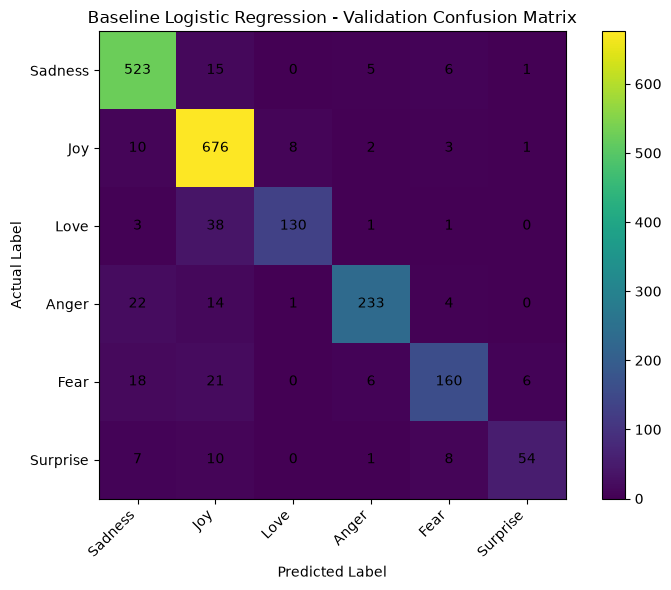

In [12]:
conf_matrix = confusion_matrix(
    y_validation,
    y_validation_pred,
)

fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(conf_matrix)

ax.set_title("Baseline Logistic Regression - Validation Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))

ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(
            j,
            i,
            conf_matrix[i, j],
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

In [13]:
confusion_df = pd.DataFrame(
    conf_matrix,
    index=[f"Actual {name}" for name in class_names],
    columns=[f"Predicted {name}" for name in class_names],
)

display(confusion_df)

,Predicted Sadness,Predicted Joy,Predicted Love,Predicted Anger,Predicted Fear,Predicted Surprise
Actual Sadness,523,15,0,5,6,1
Actual Joy,10,676,8,2,3,1
Actual Love,3,38,130,1,1,0
Actual Anger,22,14,1,233,4,0
Actual Fear,18,21,0,6,160,6
Actual Surprise,7,10,0,1,8,54


## 9. Initial Error Analysis

The confusion matrix shows that the baseline model performs strongly on the larger classes, particularly Sadness and Joy, but makes more errors on some of the smaller classes.

The most notable confusion patterns are:

- Love is most frequently misclassified as Joy.
- Fear is sometimes misclassified as Joy or Sadness.
- Anger is occasionally misclassified as Sadness or Joy.
- Surprise is sometimes misclassified as Joy or Fear.

These results suggest that some emotional expressions share overlapping vocabulary or context, making them more difficult to distinguish using TF-IDF features alone.

The lower recall observed for Love, Fear, and Surprise also reflects the class imbalance identified during dataset exploration. These classes have substantially fewer training examples than Sadness and Joy.

A class-weighted Logistic Regression model will therefore be evaluated later to determine whether minority-class recall can be improved without causing an unacceptable reduction in overall performance.

In [14]:
correct_predictions = (y_validation == y_validation_pred).sum()
incorrect_predictions = (y_validation != y_validation_pred).sum()

print("Correct predictions:", correct_predictions)
print("Incorrect predictions:", incorrect_predictions)
print("Total validation samples:", len(y_validation))

Correct predictions: 1776
Incorrect predictions: 212
Total validation samples: 1988


## 10. Misclassified Example Inspection

A sample of incorrectly classified validation records is inspected to better understand the types of language that cause errors.

This qualitative analysis complements the numerical evaluation and helps identify limitations of the TF-IDF baseline model.

In [15]:
error_analysis_df = validation_df.copy()

error_analysis_df["predicted_label"] = y_validation_pred

error_analysis_df["actual_emotion"] = error_analysis_df["label"].map(
    dict(enumerate(class_names))
)

error_analysis_df["predicted_emotion"] = error_analysis_df["predicted_label"].map(
    dict(enumerate(class_names))
)

misclassified_df = error_analysis_df[
    error_analysis_df["label"] != error_analysis_df["predicted_label"]
].copy()

print("Number of misclassified validation records:", len(misclassified_df))

display(
    misclassified_df[
        [
            "text",
            "actual_emotion",
            "predicted_emotion",
        ]
    ].head(20)
)

Number of misclassified validation records: 212


,text,actual_emotion,predicted_emotion
17,i know what it feels like he stressed glaring ...,Anger,Sadness
27,i feel as if i am the beloved preparing hersel...,Joy,Love
30,i feel like im caring about my body not in jus...,Love,Joy
40,i sit the chicken preferably bone in chicken t...,Love,Joy
41,i feel empty and i wait for new signs,Sadness,Joy
45,i cant sleep i switch on music if i need to wa...,Sadness,Joy
97,i am reading something the saints have written...,Love,Joy
114,i went from feeling helpless to powerful,Sadness,Fear
117,when i was doing research a few months ago,Anger,Joy
131,i have a lot of feelings of love and warmth fo...,Anger,Fear


### Error Analysis Observations

The baseline model produced 1,776 correct predictions and 212 incorrect predictions from 1,988 validation records.

Inspection of misclassified examples shows that several errors occur between emotionally related or linguistically overlapping classes. Examples include confusion between Love and Joy, Fear and Sadness, Anger and Sadness, and Surprise and Fear.

This suggests that TF-IDF features are effective for identifying many emotion-related words and phrases, but they have limitations when the meaning of a sentence depends heavily on context or when multiple emotional concepts share similar vocabulary.

The error patterns are also consistent with the class-level evaluation results. The minority classes Love, Fear, and Surprise achieved lower recall than the more frequent Sadness and Joy classes.

These findings provide a justification for evaluating class weighting and, later in the project, comparing the classical baseline with a transformer-based model that can represent contextual relationships between words more effectively.